# Lab 4.3: Model Diagnosis

In this lab you will implement the training set size experiment described in class, and also explore transfer learning using a pre-trained convolutional neural network (CNN) for image classification.

We will use the [Intel Image Classification dataset](https://www.kaggle.com/datasets/puneet6060/intel-image-classification).

In [15]:
!curl -sL -o intel_image_classification.zip "https://www.dropbox.com/scl/fi/7a69ka8kpdw40pm6uz91t/intel_image_classification.zip?rlkey=3knd7qsk6cvecw1mq7ohk39ot&dl=1"
!unzip -n -q intel_image_classification.zip

In [16]:
import glob
import imageio
import skimage
from matplotlib import pyplot as plt
import numpy as np

import torch
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

from tqdm import tqdm


Here is some code to load the dataset.

In [17]:
label_names = ['buildings','forest','glacier','mountain','sea','street']

In [18]:
def load_split(split):
    images = []
    labels = []
    for label in label_names:
        image_paths = sorted(glob.glob(f'intel_image_classification/seg_{split}/{label}/*.jpg'))
        for path in tqdm(image_paths, desc=f'Loading {split} images for {label}'):
            image = imageio.imread(path)
            if len(image.shape)<3:
                continue
            if image.shape[2]!=3:
                continue
            images.append(torch.tensor(image).permute(2,0,1))
            labels.append(label)
    return images, np.array(labels)

train_images, train_labels = load_split('train')
test_images, test_labels = load_split('test')

Loading train images for buildings:   0%|          | 0/2191 [00:00<?, ?it/s]/var/folders/ml/b5kpdv8s2z7ct_t3w2cjjqrm0000gn/T/ipykernel_9178/1970331604.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(path)
Loading test images for street: 100%|██████████| 501/501 [00:00<00:00, 1348.19it/s]


Text(0.5, 1.0, 'buildings')

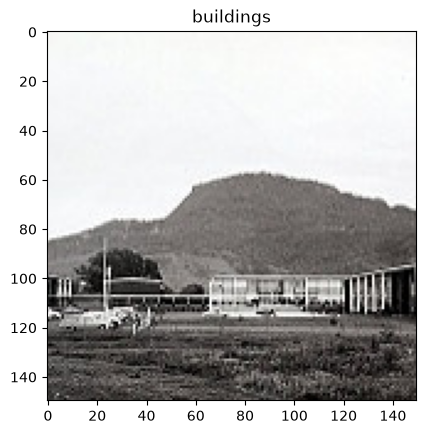

In [19]:
plt.imshow(train_images[0].permute(1,2,0))
plt.title(train_labels[0])

Here we randomly shuffle the training set, to support our later experiments.

In [20]:
inds = list(range(len(train_images)))
np.random.shuffle(inds)
train_images = [train_images[i] for i in inds]
train_labels = train_labels[inds]

Now we have arrays `train_images` and `train_labels` containing the images and labels for the training set, and the same for the test set.

Here we create a [MobileNetV2](https://arxiv.org/abs/1801.04381) model and download its pre-trained weights.  MobileNetV2 is a lightweight but high-performing convolutional neural network.  This version has been pre-trained on the ImageNet-1K dataset.

On Colab, go to `Runtime > Change Runtime Type` and select `T4 GPU` to make the CNN run faster.

In [21]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'

weights = MobileNet_V2_Weights.IMAGENET1K_V2
mobilenet = mobilenet_v2(weights=weights)
# remove last layer
mobilenet.classifier = torch.nn.Sequential(*list(mobilenet.classifier.children())[:-1])
mobilenet = mobilenet.to(device)
mobilenet.eval()
transforms = weights.transforms()

This function will properly process the image and run MobileNetV2 to extract a feature vector.

In [22]:
def run_mobilenet(image):
    image = transforms(image)
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = mobilenet(image)
    return output[0].cpu().numpy()

1. Compute a MobileNetV2 descriptor for each image to make two lists, `train_descriptors` and `test_descriptors`, using the `run_mobilenet` function from above.

In [23]:
train_descriptors = [run_mobilenet(image) for image in tqdm(train_images, desc='Extracting train descriptors')]
test_descriptors = [run_mobilenet(image) for image in tqdm(test_images, desc='Extracting test descriptors')]

Extracting test descriptors: 100%|██████████| 3000/3000 [00:25<00:00, 118.04it/s]


2. Build a k-nearest neighbors classifier on the training set (```sklearn.neighbors.KNeighborsClassifier```).

This model will find the $k$ nearest neighbors to the query point and output the most common label.  Use $k=10$.

Run the model on the training and testing sets and print out the accuracy score for each (```sklearn.metrics.accuracy_score``` or simply use ```model.score```).

In [28]:
knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(train_descriptors,train_labels)

print(knn.score(train_descriptors, train_labels))
print(knn.score(test_descriptors, test_labels))



0.9223314806897535
0.916


3. Now let's explore how train and test accuracy change as training set size increases.

We will test a range of training set sizes in increments of 1000 (so 1000, 2000, 3000, ... up to the original size of the training set).

For each size setting $s$, fit a ```kNeighborsClassifer``` model to the first $s$ examples in the training set.   Use $k=10$.

Then compute the accuracy of the model on the chosen subset of the training set, and the entire test set.  *Note: always use the entire test set!*


In [30]:
sizes = list(range(1000, len(train_descriptors) + 1, 1000))
train_accuracies = []
test_accuracies = []

for s in tqdm(sizes):
    knn = KNeighborsClassifier(n_neighbors=10)
    knn.fit(train_descriptors[:s], train_labels[:s])
    train_accuracies.append(knn.score(train_descriptors[:s], train_labels[:s]))
    test_accuracies.append(knn.score(test_descriptors, test_labels))


print(train_accuracies)
print(test_accuracies)


100%|██████████| 14/14 [00:12<00:00,  1.08it/s]

[0.891, 0.9015, 0.909, 0.9135, 0.9132, 0.9128333333333334, 0.9127142857142857, 0.915875, 0.916, 0.9188, 0.9190909090909091, 0.9193333333333333, 0.9205384615384615, 0.9219285714285714]
[0.8843333333333333, 0.89, 0.8933333333333333, 0.8966666666666666, 0.8956666666666667, 0.8996666666666666, 0.9033333333333333, 0.9083333333333333, 0.9103333333333333, 0.9116666666666666, 0.9116666666666666, 0.9123333333333333, 0.9143333333333333, 0.916]


Make a plot of the two accuracy values as the training set size increases.  Put both lines on the same plot.

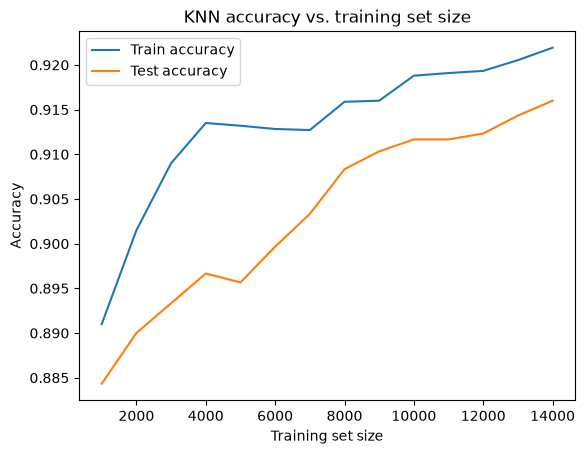

In [31]:
plt.plot(sizes, train_accuracies, label='Train accuracy')
plt.plot(sizes, test_accuracies, label='Test accuracy')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('KNN accuracy vs. training set size')
plt.legend()
plt.show()

Analyze the results.  If we want to improve the model's test set accuracy, what should we do -- add more training data, or choose a different model?

It looks like both accuracies are monotonically increasing, so we have room to add more train data and experience better train and test accuracy. Similarly, the distance between the two curves is relatively small, which I think is a good sign that we haven't approached bad overfitting yet.